In [2]:
from prophet import Prophet
from prophet.plot import plot_plotly
import plotly.offline as py
py.init_notebook_mode()

c:\Users\fatou\OneDrive\Desktop\448Training\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import numpy as numpy
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('fivethirtyeight')

In [4]:
df=pd.read_csv("NYC_Central_Park_weather_1869-2022.csv")
print(df.head())
df["DATE"]=pd.to_datetime(df["DATE"])
df.info()


         DATE  PRCP  SNOW  SNWD  TMIN  TMAX
0  1869-01-01  0.75   9.0   NaN  19.0  29.0
1  1869-01-02  0.03   0.0   NaN  21.0  27.0
2  1869-01-03  0.00   0.0   NaN  27.0  35.0
3  1869-01-04  0.18   0.0   NaN  34.0  37.0
4  1869-01-05  0.05   0.0   NaN  37.0  43.0
<class 'pandas.DataFrame'>
RangeIndex: 56245 entries, 0 to 56244
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   DATE    56245 non-null  datetime64[us]
 1   PRCP    56245 non-null  float64       
 2   SNOW    56082 non-null  float64       
 3   SNWD    39687 non-null  float64       
 4   TMIN    56238 non-null  float64       
 5   TMAX    56238 non-null  float64       
dtypes: datetime64[us](1), float64(5)
memory usage: 2.6 MB


In [5]:
df["Month"]=df["DATE"].dt.month
df["Year"]=df["DATE"].dt.year
dfPrcp=df[["DATE", "Month", "Year", "PRCP"]]
dfSnow=df[["DATE", "Month", "Year", "SNOW", "SNWD"]]
dfTemp=df[["DATE", "Month", "Year", "TMIN", "TMAX"]]

#dfPrcp=dfPrcp.rename(columns={"DATE": "ds", "PRCP": "y"})
#dfSnow=dfSnow.rename(columns={"DATE": "ds", "PRCP": "y"})
#dfTemp=dfTemp.rename(columns={"DATE": "ds", "PRCP": "y"})

#print(dfPrcp.head())
#print(dfSnow.head())
#print(dfTemp.head())


In [6]:

print(dfPrcp.head())
print(dfSnow.head())
print(dfTemp.head())

        DATE  Month  Year  PRCP
0 1869-01-01      1  1869  0.75
1 1869-01-02      1  1869  0.03
2 1869-01-03      1  1869  0.00
3 1869-01-04      1  1869  0.18
4 1869-01-05      1  1869  0.05
        DATE  Month  Year  SNOW  SNWD
0 1869-01-01      1  1869   9.0   NaN
1 1869-01-02      1  1869   0.0   NaN
2 1869-01-03      1  1869   0.0   NaN
3 1869-01-04      1  1869   0.0   NaN
4 1869-01-05      1  1869   0.0   NaN
        DATE  Month  Year  TMIN  TMAX
0 1869-01-01      1  1869  19.0  29.0
1 1869-01-02      1  1869  21.0  27.0
2 1869-01-03      1  1869  27.0  35.0
3 1869-01-04      1  1869  34.0  37.0
4 1869-01-05      1  1869  37.0  43.0


In [7]:
dfPrcpbyMonth=dfPrcp.groupby(["Month", "Year"])["PRCP"].mean().reset_index()
dfSnowbyMonth=dfSnow.groupby(["Month", "Year"])["SNOW"].mean().reset_index()
dfTempbyMonth=dfTemp.groupby(["Month", "Year"])["TMAX"].mean().reset_index()
#print(dfPrcpbyMonth)


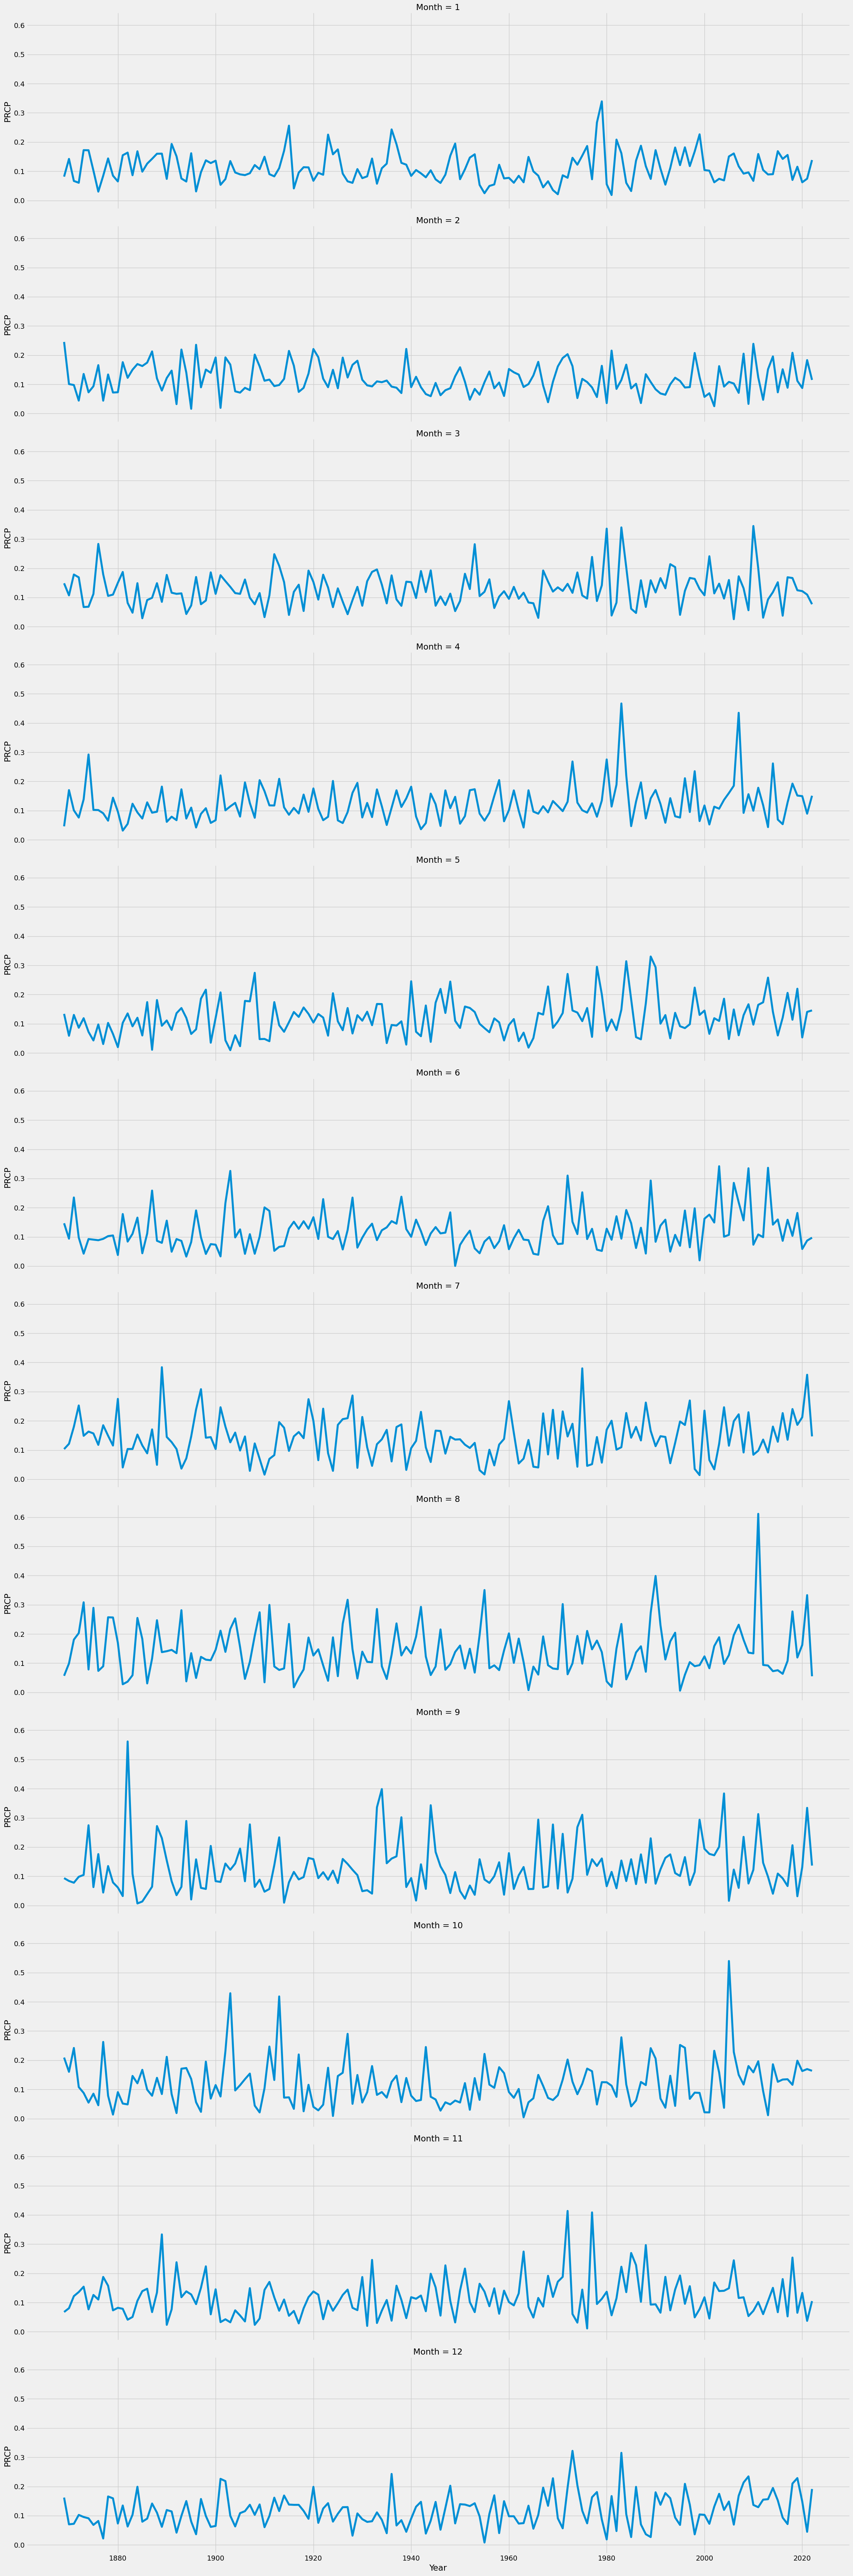

In [8]:
#For Rain
sns.relplot(x="Year", 
            y="PRCP", 
            data=dfPrcpbyMonth, 
            kind="line", 
            row="Month",
            height=6,
            aspect=4)
plt.show()


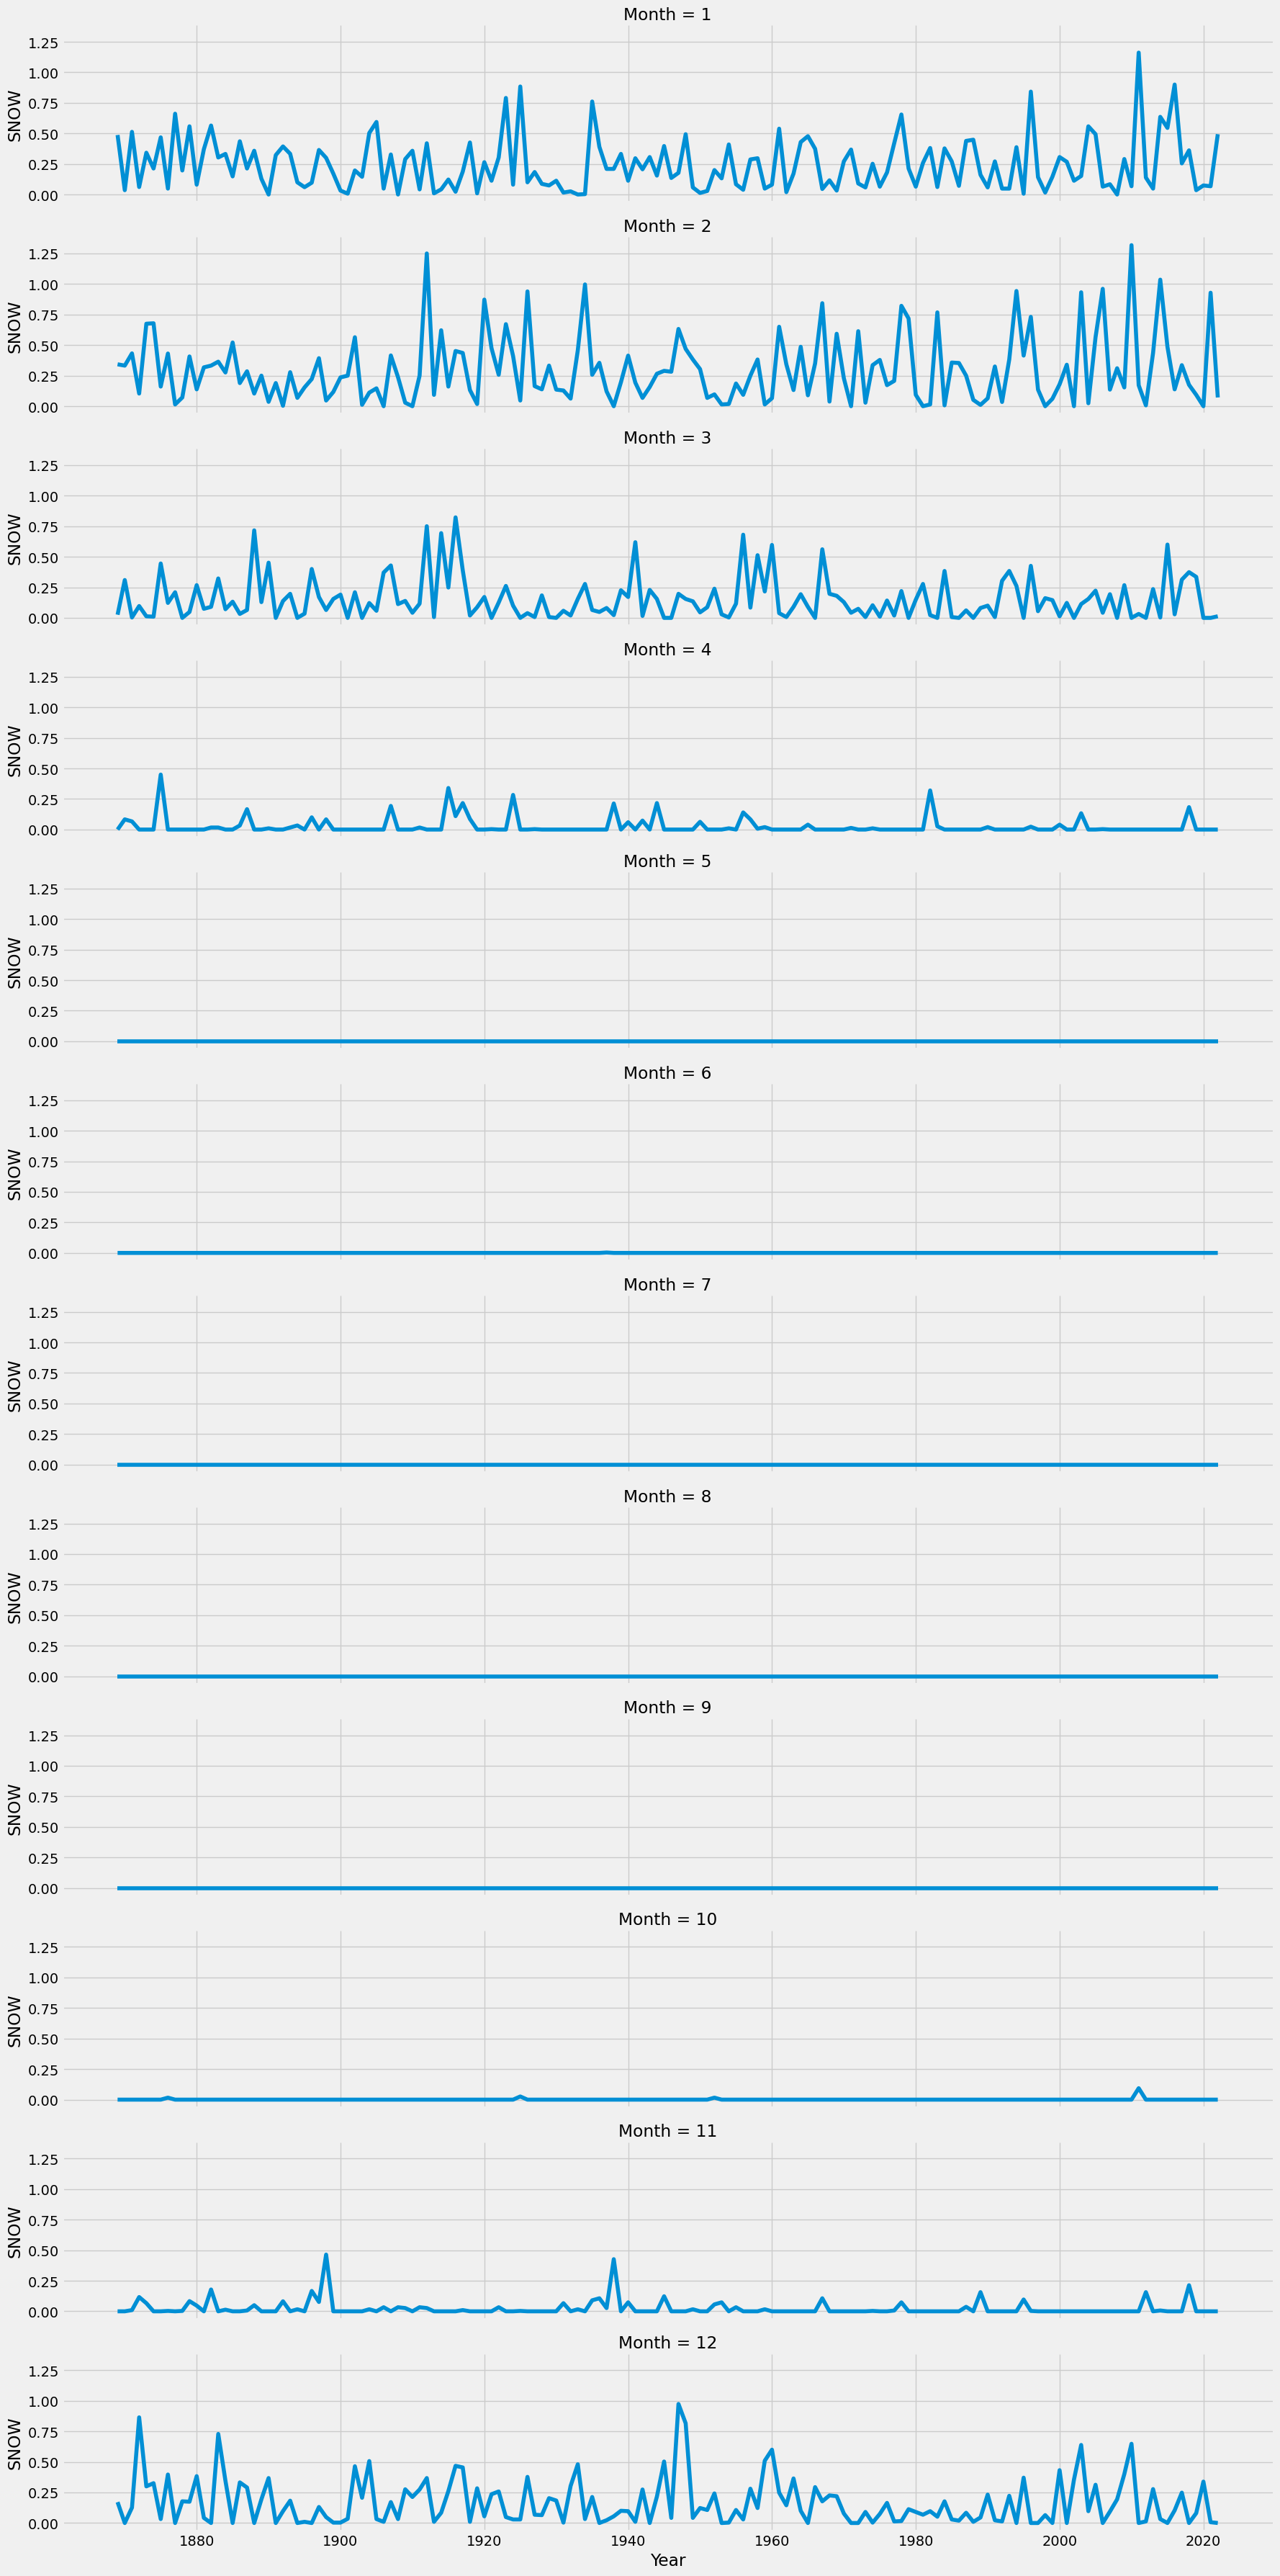

In [13]:
#For Snow
sns.relplot(x="Year",
            y="SNOW",
            data=dfSnowbyMonth,
            kind="line",
            row="Month",
            height=3,
            aspect=6)
plt.show()

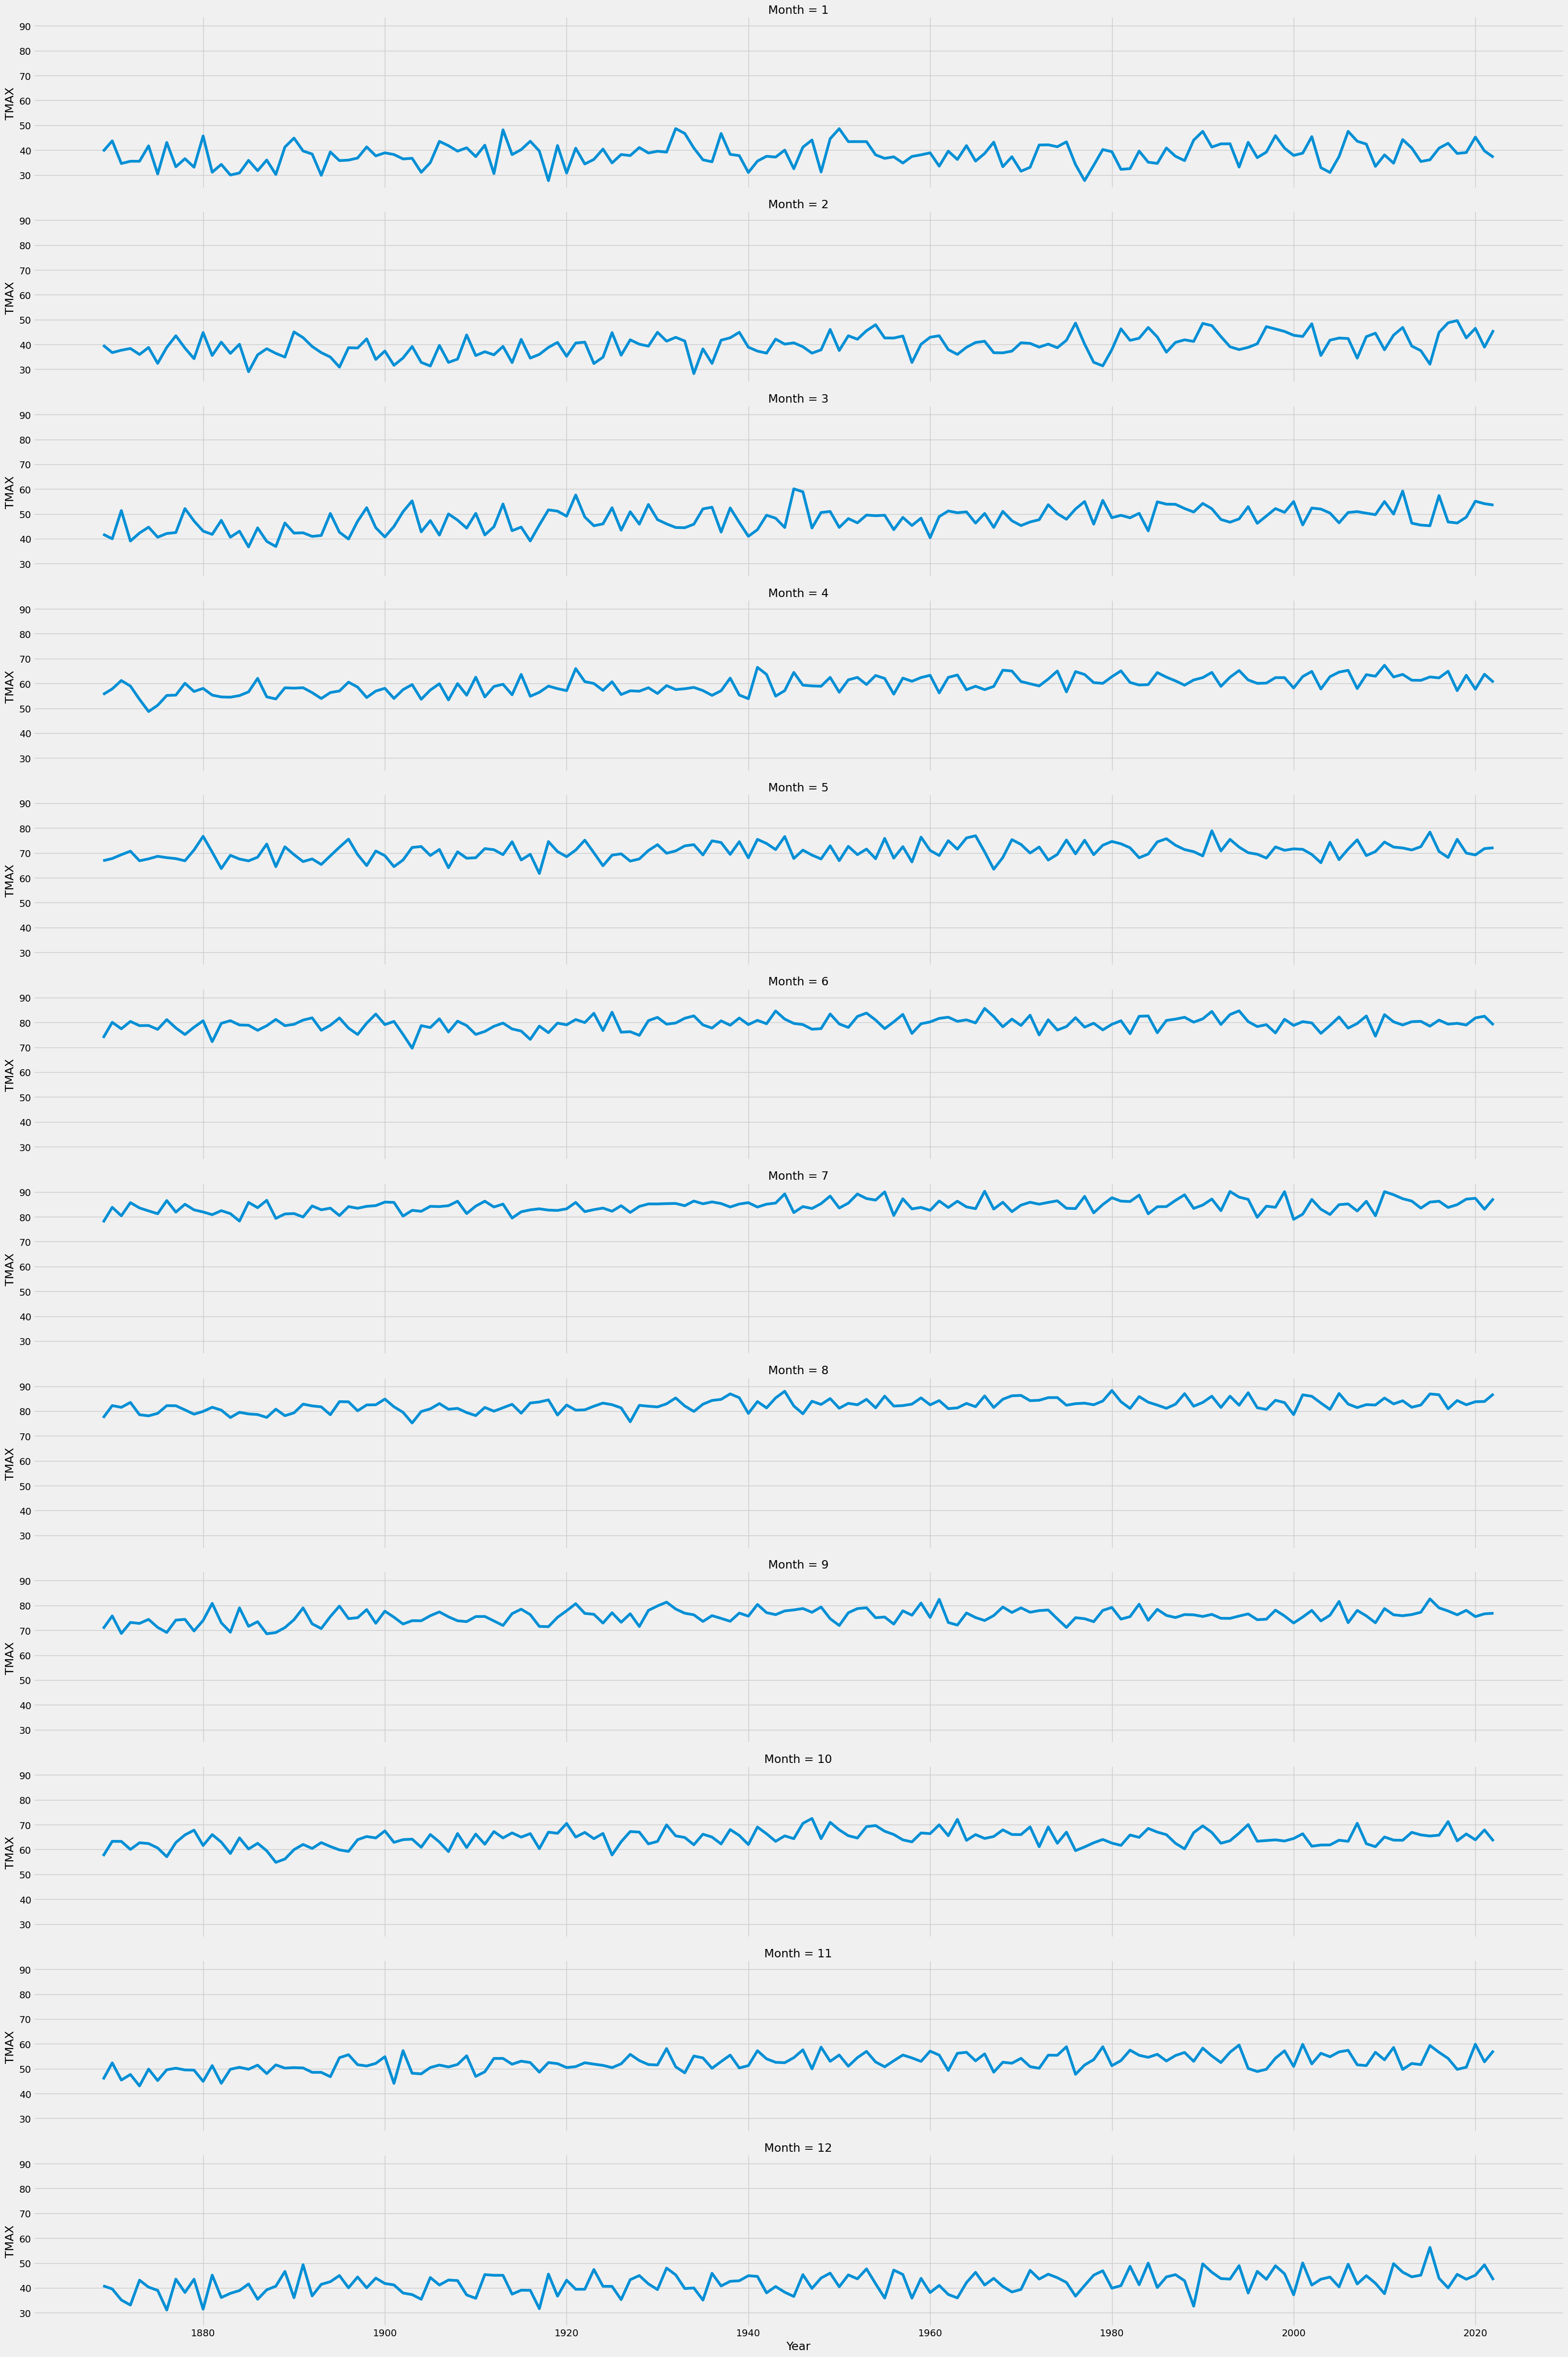

In [20]:
#For Temperature
sns.relplot(x="Year",
            y="TMAX",
            data=dfTempbyMonth,
            kind="line",
            row="Month",
            height=4,
            aspect=8)

In [24]:
#Temperature Differences
dfTempbyMonth["Diff"]=dfTemp["TMAX"]-dfTemp["TMIN"]
print(dfTempbyMonth.head())

   Month  Year       TMAX  Diff
0      1  1869  39.516129  10.0
1      1  1870  43.709677   6.0
2      1  1871  34.612903   8.0
3      1  1872  35.516129   3.0
4      1  1873  35.516129   6.0


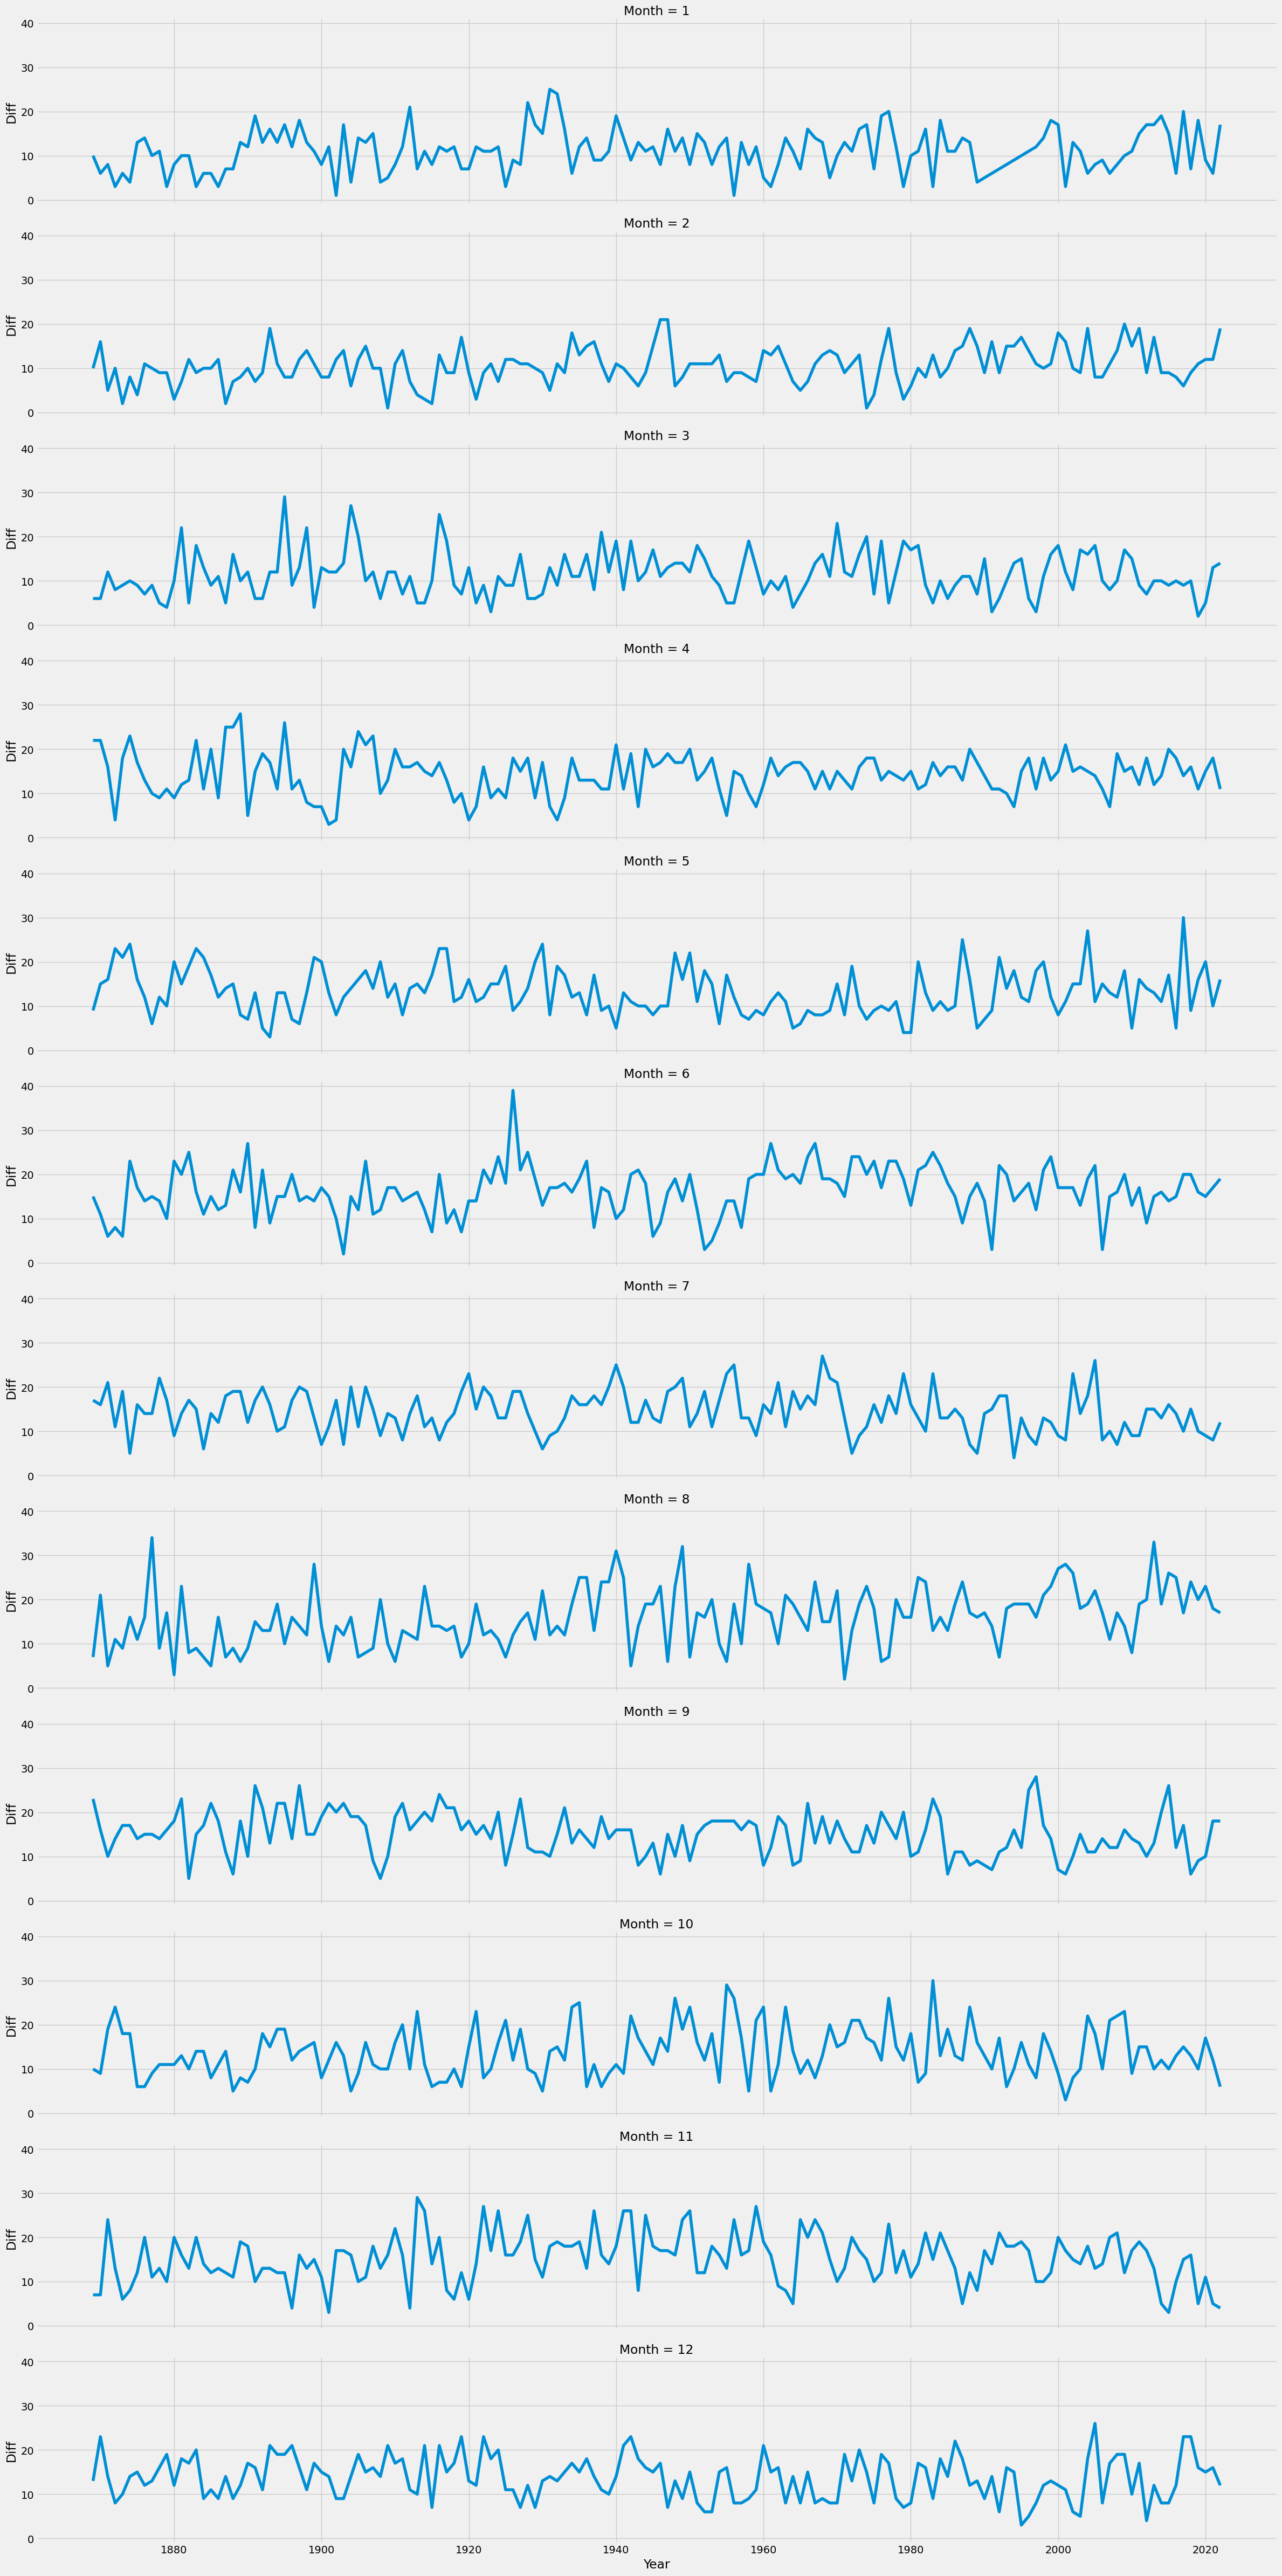

In [26]:
sns.relplot(x="Year",
            y="Diff",
            data=dfTempbyMonth,
            kind="line",
            row="Month",
            height=4,
            aspect=6)

In [ ]:
#